In [2]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image
import os
from paddle.vision.transforms import functional as F


In [3]:
def get_color_map_list(num_classes):
    """
    Returns the color map for visualizing the segmentation mask,
    which can support arbitrary number of classes.
    Args:
        num_classes (int): Number of classes.
    Returns:
        (list). The color map.
    """

    num_classes += 1
    color_map = num_classes * [0, 0, 0]
    for i in range(0, num_classes):
        j = 0
        lab = i
        while lab:
            color_map[i * 3] |= (((lab >> 0) & 1) << (7 - j))
            color_map[i * 3 + 1] |= (((lab >> 1) & 1) << (7 - j))
            color_map[i * 3 + 2] |= (((lab >> 2) & 1) << (7 - j))
            j += 1
            lab >>= 3
    color_map = color_map[3:]
    return color_map

d:\Anaconda\envs\paddle_env\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [4]:
color_map = get_color_map_list(256)

In [5]:
src_img_path = "C:\\Users\\hp\\Desktop\\4_rect_1\\leftImg8bit"
src_mask_path = "C:\\Users\\hp\\Desktop\\4_rect_1\\gtFine"
save_img_path = "C:\\Users\\hp\\Desktop\\4_aug\\leftImg8bit"
save_mask_path = "C:\\Users\\hp\\Desktop\\4_aug\\gtFine"

In [6]:
imgs_name = []
for _item in os.listdir(src_img_path):
    if _item.split('.')[-1] in ['jpg', 'png', 'bmp', 'jpeg']:
        imgs_name.append(_item)

In [9]:
# 颜色改变
per_num = 150
dist_arr = np.linspace(1, 100, num=100) #随机选择的数组
bright_arr = np.hstack((np.linspace(0.8,0.99, 30), np.linspace(1.1,2,100))) # 变暗的少，变亮的多

_imgName = '4.jpg'
_maskName = '4.png'

for i in range(0, per_num):

    img = Image.open(os.path.join(src_img_path, _imgName))#加载图片
    img_mask = Image.open(os.path.join(src_mask_path, _maskName))
    img_mask = np.array(img_mask)
    # 亮度变换最主要
    _bright_factor = np.random.choice(bright_arr)
    converted_img = F.adjust_brightness(img, _bright_factor)
    # 随机选择一个数决定是否使用下面的变换
    _flag = np.random.choice(dist_arr) 
    if _flag>=70.:
        #对比度
        _contrast_factor = np.random.choice([0.55,0.6,0.65,0.7,0.75,0.8,0.9,1.2,1.3,1.4,1.5,1.6])
        converted_img = F.adjust_contrast(converted_img,_contrast_factor)

        # 饱和度
        _saturation_factor = np.random.choice([0.6,0.65,0.7,0.75,0.8,0.9,0.91,0.92,0.93,0.94,0.95,0.96])
        converted_img = F.adjust_saturation(converted_img, _saturation_factor)
    if _flag > 90:
        # 色调
        _hue_factor = np.random.choice([-0.3,-0.2,-0.15,-0.1,-0.05,-0.02,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08
                                        ,0.09,0.1,0.11,0.12,0.13,0.14,0.15,0.2,0.3])
        converted_img = F.adjust_hue(converted_img,_hue_factor) #[-0.5,0.5]
    # 保存新图片和标签
    _new_img_name = _imgName.split('.')[0]+'_'+str(i)+'.'+_imgName.split('.')[-1]
    converted_img.save(os.path.join(save_img_path, _new_img_name))

    new_img_mask = img_mask
    lbl_pil = Image.fromarray(new_img_mask.astype(np.uint8), mode='P')
    lbl_pil.putpalette(color_map)
    _new_mask_name = _maskName.split('.')[0]+'_'+str(i)+'.'+_maskName.split('.')[-1]
    lbl_pil.save(os.path.join(save_mask_path, _new_mask_name))



In [7]:
# 获得一个可用的背景色
def get_full_color(image_src, rect):
    _average_colors = image_src[rect[0]:rect[1], rect[2]:rect[3],:]
    average_color = _average_colors.reshape(-1,3)
    _len = len(average_color)
    average_color = average_color.astype(np.float32)
    average_color = np.sum(average_color, axis=0)/_len
    average_color = average_color.astype(np.uint8)
    return average_color

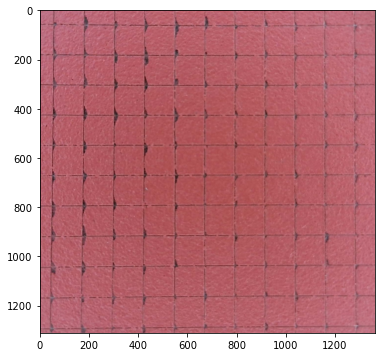

In [56]:
img = Image.open(os.path.join(src_img_path, '17.jpg'))#加载图片
plt.figure(figsize=(6,6))
plt.imshow(img)

In [8]:
bg_dict = {'1.jpg':[1200, 1210, 200, 250], '2.jpg':[1200, 1210, 200, 250], '3.jpg':[1200, 1210, 200, 250], 
           '4.jpg':[1200, 1210, 200, 250], '5.jpg':[1200, 1210, 200, 250], '6.jpg':[1200, 1210, 200, 250], 
           '7.jpg':[1200, 1210, 200, 250], '8.jpg':[1200, 1210, 200, 250], '9.jpg':[1200, 1210, 200, 250], 
           '10.jpg':[1200, 1210, 200, 250], '11.jpg':[1200, 1210, 150, 200], '12.jpg':[1200, 1210, 200, 250], 
           '13.jpg':[1200, 1210, 200, 250], '14.jpg':[1200, 1210, 200, 250], '15.jpg':[1200, 1210, 200, 250],
           '16.jpg':[1200, 1210, 200, 250], '17.jpg':[1200, 1210, 200, 230] }

In [9]:
src_bg_path = "C:\\Users\\hp\\Desktop\\4_rect_1\\bg"

In [10]:
# 原图片本身旋转
# _imgName = '4.jpg'
# _maskName = '4.png'
angles_list = np.linspace(1, 359, 70)
angles_list = angles_list.astype(np.int32)

for _imgName in imgs_name:
    _maskName = _imgName.split('.')[0] + '.png'
    
    for angle in angles_list:
        img = Image.open(os.path.join(src_img_path, _imgName))#加载图片
        img_bg = Image.open(os.path.join(src_bg_path, _imgName))#加载图片
        img_mask = Image.open(os.path.join(src_mask_path, _maskName))
        
        img2 = img.rotate(angle)
        img_mask2 = img_mask.rotate(angle)
        
        img2_arr = np.array(img2)
        img_bg = np.array(img_bg)
        img = np.array(img)
        # R,G,B的值均为0才是黑色
        img2_arr_mask = np.logical_and(img2_arr[:,:,0] == 0 , img2_arr[:,:,1] == 0) # 求R和G通道bool矩阵的交集
        img2_arr_mask = np.logical_and(img2_arr_mask, img2_arr[:,:,2] == 0)
        # full_color = get_full_color(np.array(img), bg_dict[_imgName])
        # img2_arr[img2_arr_mask]= np.array([255,255,122], dtype=np.uint8)
        img2_arr[img2_arr_mask]= img_bg[img2_arr_mask]
        
        # 保存新图片和标签
        _new_img_name = _imgName.split('.')[0]+'_'+str(angle)+'deg'+'.'+_imgName.split('.')[-1]
        converted_img = Image.fromarray(img2_arr)
        converted_img.save(os.path.join(save_img_path, _new_img_name))

        lbl_pil = img_mask2
        lbl_pil.putpalette(color_map)
        _new_mask_name = _maskName.split('.')[0]+'_'+str(angle)+'deg'+'.'+_maskName.split('.')[-1]
        lbl_pil.save(os.path.join(save_mask_path, _new_mask_name))
    
    

KeyboardInterrupt: 